In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Iris.csv to Iris (1).csv


In [ ]:
df = pd.read_csv("Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Shape: (150, 6)

Columns:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Data Types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


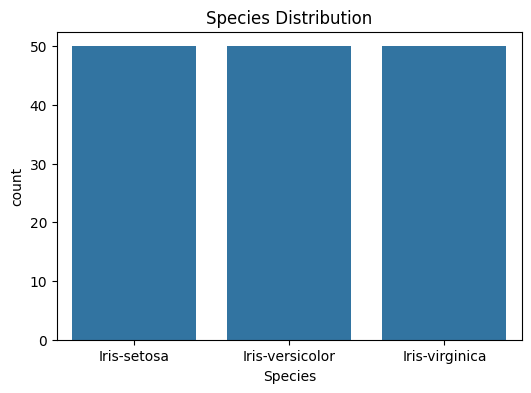

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Species",
    data=df
)

plt.title("Species Distribution")

plt.show()

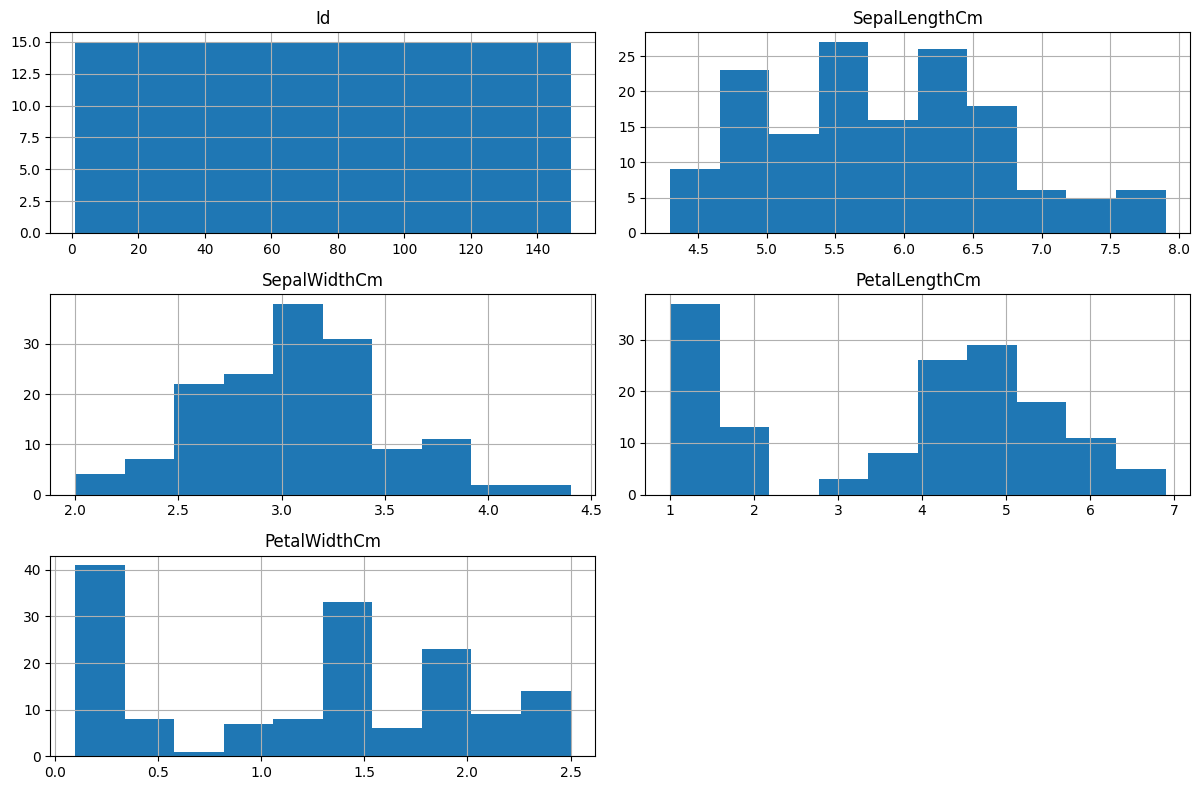

In [ ]:
df.hist(
    figsize=(12,8)
)

plt.tight_layout()

plt.show()

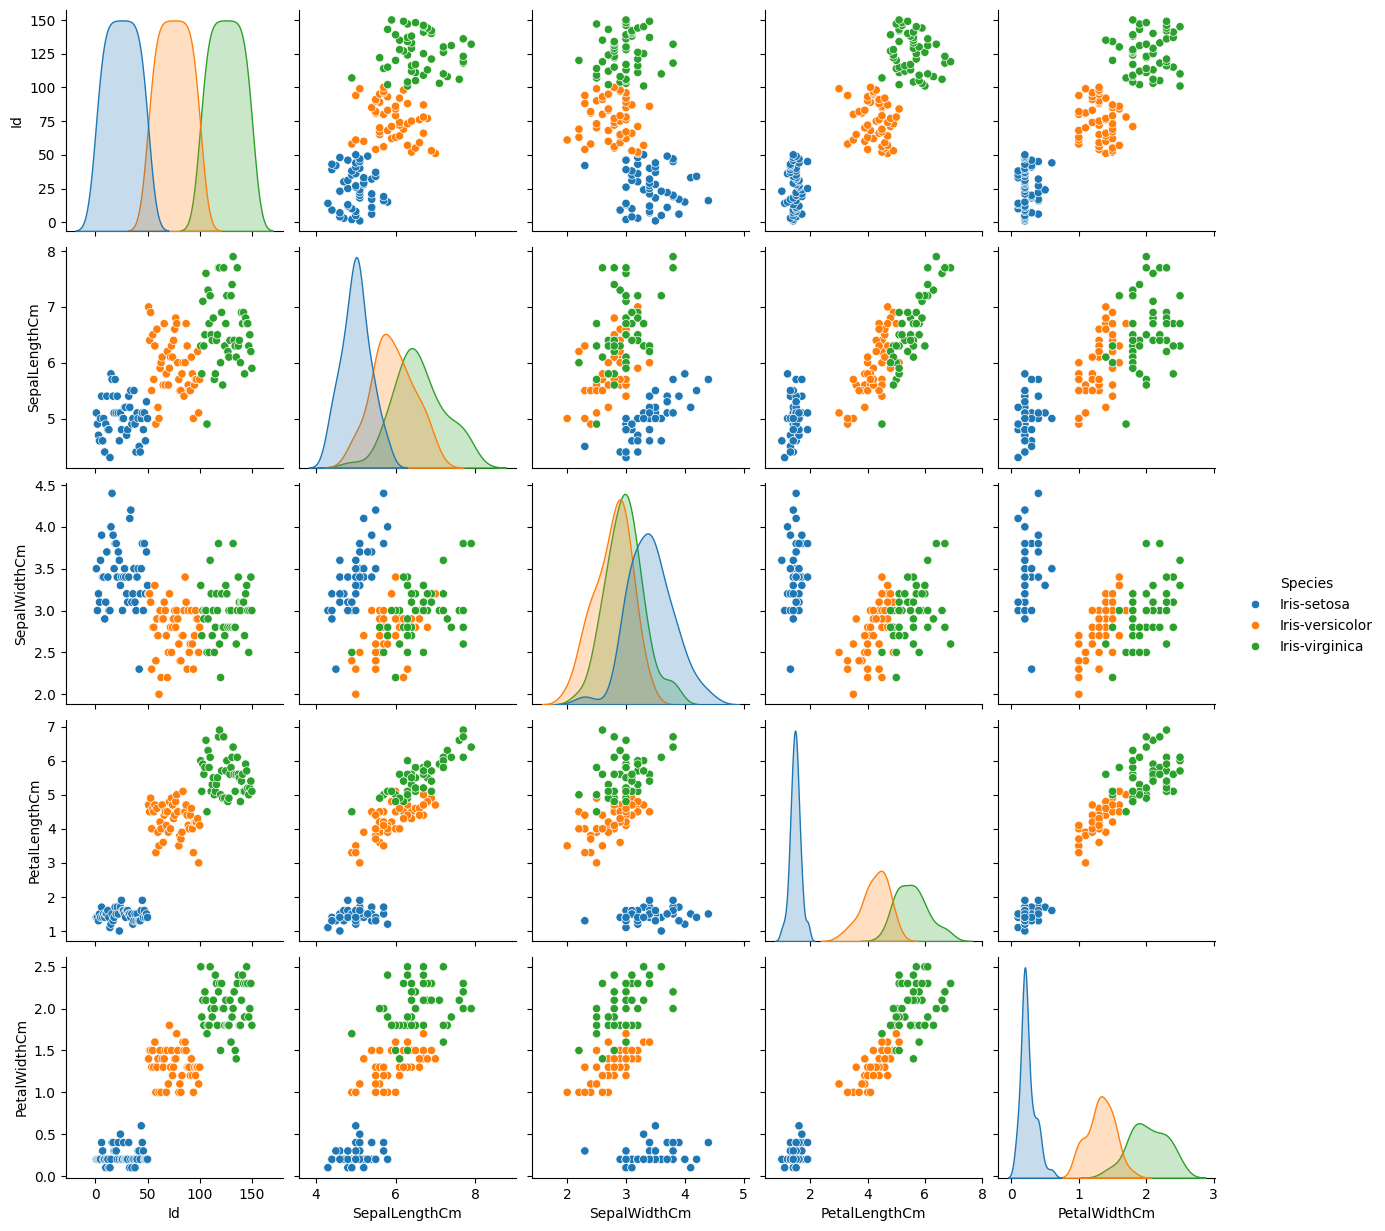

In [ ]:
sns.pairplot(
    df,
    hue="Species"
)

plt.show()

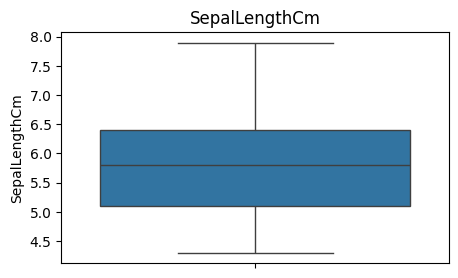

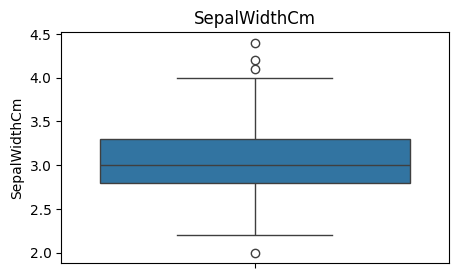

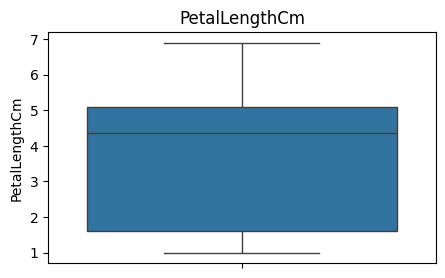

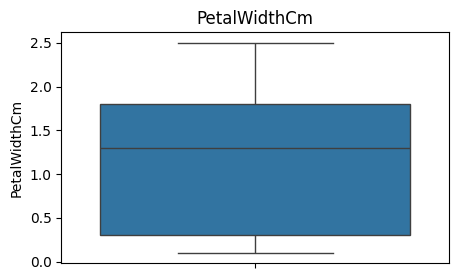

In [ ]:
for column in [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]:

    plt.figure(figsize=(5,3))

    sns.boxplot(
        y=df[column]
    )

    plt.title(column)

    plt.show()

In [ ]:
df.drop(
    "Id",
    axis=1,
    inplace=True
)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


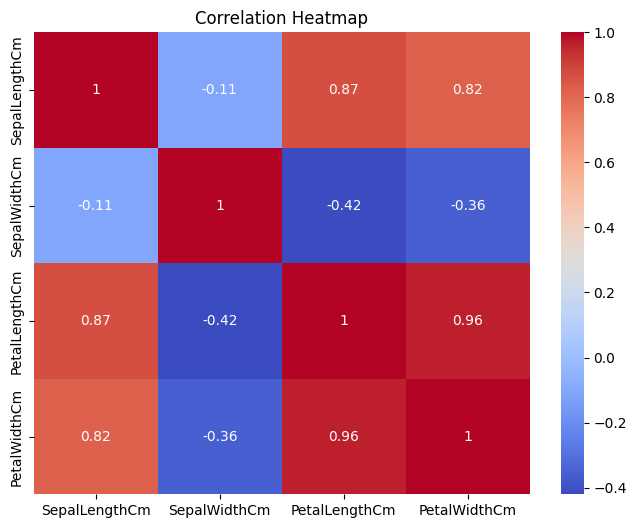

In [ ]:
numeric_df = df.drop(
    "Species",
    axis=1
)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
df.groupby(
    "Species"
).mean()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [ ]:
df["Sepal_Area"] = (
    df["SepalLengthCm"] *
    df["SepalWidthCm"]
)

df["Petal_Area"] = (
    df["PetalLengthCm"] *
    df["PetalWidthCm"]
)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Sepal_Area,Petal_Area
0,5.1,3.5,1.4,0.2,Iris-setosa,17.85,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,14.70,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,15.04,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,14.26,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,18.00,0.28


In [ ]:
encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(
    df["Species"]
)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Sepal_Area,Petal_Area
0,5.1,3.5,1.4,0.2,0,17.85,0.28
1,4.9,3.0,1.4,0.2,0,14.70,0.28
2,4.7,3.2,1.3,0.2,0,15.04,0.26
3,4.6,3.1,1.5,0.2,0,14.26,0.30
4,5.0,3.6,1.4,0.2,0,18.00,0.28


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print("Logistic Regression:", lr_acc)

Logistic Regression: 0.9333333333333333


In [ ]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(
    y_test,
    knn_pred
)

print("KNN:", knn_acc)

KNN: 0.9333333333333333


In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree:", dt_acc)

Decision Tree: 0.9


In [ ]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest:", rf_acc)

Random Forest: 0.9333333333333333


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[50,100,150,200],
    "max_depth":[2,3,5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5
)

grid.fit(
    X_train,
    y_train
)

print(grid.best_params_)

{'max_depth': 3, 'n_estimators': 50}


In [ ]:
best_rf = grid.best_estimator_

best_pred = best_rf.predict(
    X_test
)

best_acc = accuracy_score(
    y_test,
    best_pred
)

print("Best Accuracy:", best_acc)

Best Accuracy: 0.9666666666666667


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_rf,
    X_scaled,
    y,
    cv=5
)

print(scores)

print("Average Accuracy:", scores.mean())

[0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Average Accuracy: 0.96


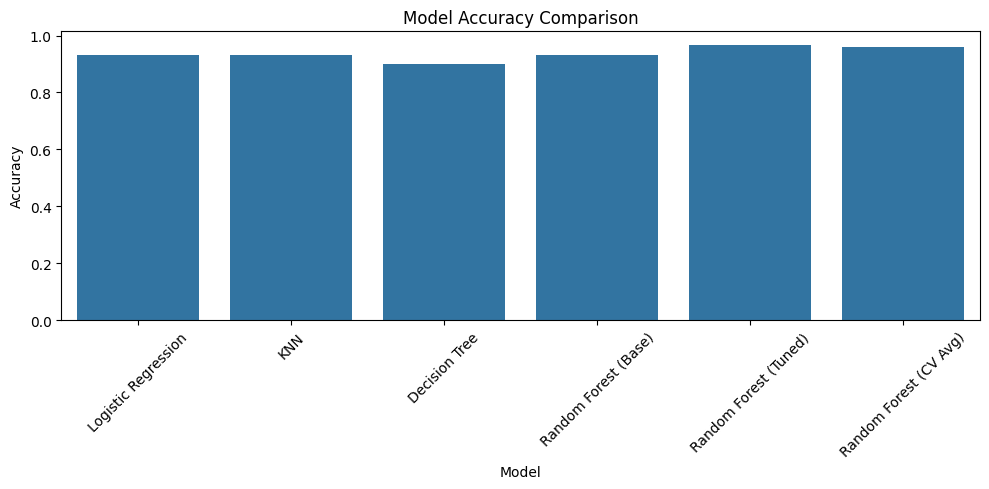

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
results = pd.DataFrame({

    "Model":[
        "LogReg",
        "KNN",
        "DT",
        "RF",
        "RF-Tuned",
        "RF-CV"
    ],

    "Accuracy":[
        lr_acc,
        knn_acc,
        dt_acc,
        rf_acc,
        best_acc,
        scores.mean()
    ]
})

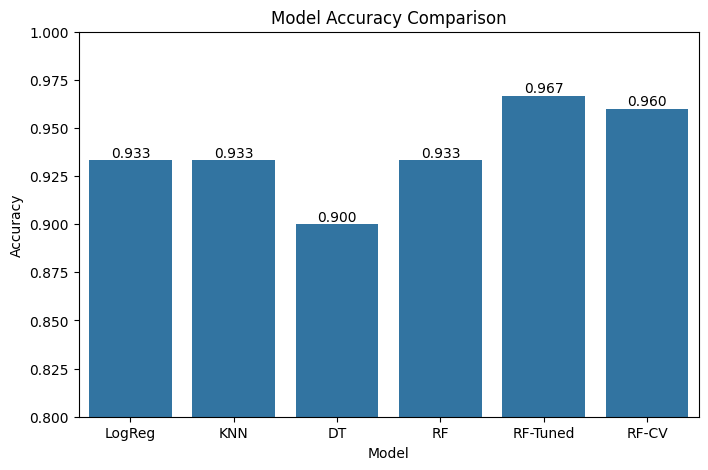

In [ ]:

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

for i in ax.containers:
    ax.bar_label(i, fmt="%.3f")

plt.title("Model Accuracy Comparison")

plt.ylim(0.8,1.0)

plt.show()

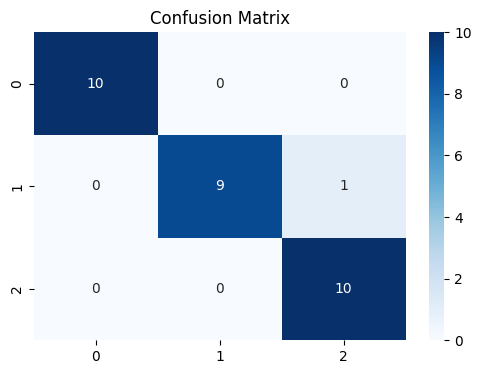

In [ ]:
cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,PetalLengthCm,0.444206
3,PetalWidthCm,0.435467
0,SepalLengthCm,0.114296
1,SepalWidthCm,0.006031


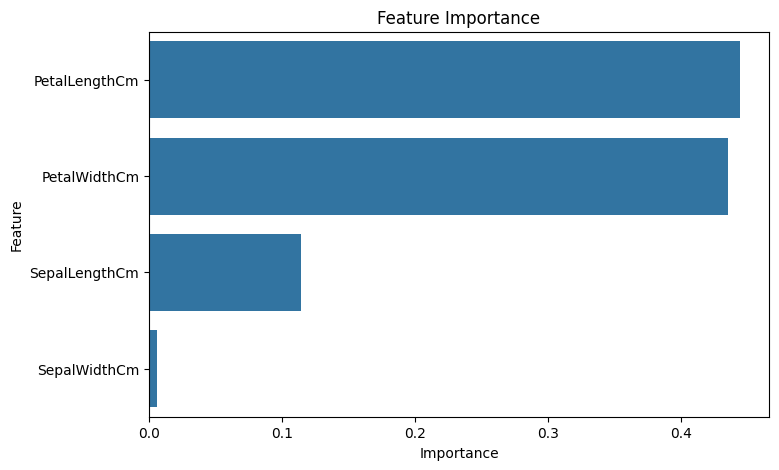

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title(
    "Feature Importance"
)

plt.show()

In [ ]:
sample = [[
    5.1,
    3.5,
    1.4,
    0.2
]]

sample = scaler.transform(sample)

prediction = best_rf.predict(sample)

print(
    encoder.inverse_transform(
        prediction
    )
)

['Iris-setosa']
